In [ ]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
	def __init__(self, training_images_filepath,training_labels_filepath,
				 test_images_filepath, test_labels_filepath):
		self.training_images_filepath = training_images_filepath
		self.training_labels_filepath = training_labels_filepath
		self.test_images_filepath = test_images_filepath
		self.test_labels_filepath = test_labels_filepath
	
	def read_images_labels(self, images_filepath, labels_filepath):        
		labels = []
		with open(labels_filepath, 'rb') as file:
			magic, size = struct.unpack(">II", file.read(8))
			if magic != 2049:
				raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
			labels = array("B", file.read())        
		
		with open(images_filepath, 'rb') as file:
			magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
			if magic != 2051:
				raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
			image_data = array("B", file.read())        
		images = []
		for i in range(size):
			images.append([0] * rows * cols)
		for i in range(size):
			img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
			img = img.reshape(28, 28)
			images[i][:] = img            
		
		return images, labels
			
	def load_data(self):
		x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
		x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
		return (x_train, y_train),(x_test, y_test)        

In [ ]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = '.'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
	cols = 5
	rows = int(len(images)/cols) + 1
	plt.figure(figsize=(30,20))
	index = 1    
	for x in zip(images, title_texts):        
		image = x[0]        
		title_text = x[1]
		plt.subplot(rows, cols, index)        
		plt.imshow(image, cmap=plt.cm.gray)
		if (title_text != ''):
			plt.title(title_text, fontsize = 15);        
		index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
	r = random.randint(1, 60000)
	images_2_show.append(x_train[r])
	titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
	r = random.randint(1, 10000)
	images_2_show.append(x_test[r])        
	titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

# show_images(images_2_show, titles_2_show)



In [ ]:
from PIL import Image

seed = 71 # Kierunkowy na Wrocław :)
rng = np.random.default_rng(seed)


n_samples_per_class = 144
n_subsets = 5
n_classes = 10
resolution = (16, 16)
bitrate_quantization = 4

# 1. Zamień etykiety na NumPy array, jeśli jeszcze nim nie są
y_train_np = np.array(y_train)

# 2. Przygotuj listę subsetów
subsets = []

for subset_idx in range(n_subsets):
	subsets.append({
		"X": [],
		"y": []
	})

# 3. Dla każdej klasy:
for cls in range(n_classes):
	# indeksy wszystkich próbek danej klasy
	class_indices = np.where(y_train_np == cls)[0]

	# sprawdzenie, czy starczy danych na 5 rozłącznych subsetów
	required = n_subsets * n_samples_per_class
	if len(class_indices) < required:
		raise ValueError(
			f"Klasa {cls} ma tylko {len(class_indices)} próbek, "
			f"a potrzeba co najmniej {required}."
		)

	# deterministyczne tasowanie
	shuffled_indices = rng.permutation(class_indices)

	# 4. Podział na 5 kolejnych bloków po 150 próbek
	for subset_idx in range(n_subsets):
		start = subset_idx * n_samples_per_class
		end = (subset_idx + 1) * n_samples_per_class
		subset_indices = shuffled_indices[start:end]

		for image_idx in subset_indices:
			img_8x8 = Image.fromarray(np.array(x_train[image_idx])).resize(
				resolution,
				resample=Image.BILINEAR
			)
			img = np.array(img_8x8)

			img_4bit = np.round(img / 2**bitrate_quantization) * 2**bitrate_quantization
			img_4bit = np.clip(img_4bit, 0, 255).astype(np.uint8)

			subsets[subset_idx]["X"].append(img_4bit)
			subsets[subset_idx]["y"].append(cls)

# 5. Konwersja list do NumPy array
for subset_idx in range(n_subsets):
	subsets[subset_idx]["X"] = np.array(subsets[subset_idx]["X"])
	subsets[subset_idx]["y"] = np.array(subsets[subset_idx]["y"])

# Przykład użycia:
X_0, y_0 = subsets[0]["X"], subsets[0]["y"]
X_1, y_1 = subsets[1]["X"], subsets[1]["y"]
X_2, y_2 = subsets[2]["X"], subsets[2]["y"]
X_3, y_3 = subsets[3]["X"], subsets[3]["y"]
X_4, y_4 = subsets[4]["X"], subsets[4]["y"]

In [ ]:
from dataclasses import dataclass
import numpy as np

@dataclass
class DatasetSplit:
	X: np.ndarray
	y: np.ndarray

@dataclass
class DataBlock:
	train: DatasetSplit
	val: DatasetSplit
	test: DatasetSplit
	
@dataclass
class DataSet:
	subsets: list[DataBlock]
	info: dict

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.2, random_state=seed, stratify=y_0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)

block_0 = DataBlock(
	train=DatasetSplit(x_train, y_train),
	val=DatasetSplit(x_val, y_val),
	test=DatasetSplit(x_test, y_test),
)

x_train, x_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=seed, stratify=y_1)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)


block_1 = DataBlock(
	train=DatasetSplit(x_train, y_train),
	val=DatasetSplit(x_val, y_val),
	test=DatasetSplit(x_test, y_test),
)

x_train, x_test, y_train, y_test = train_test_split(X_2, y_2, test_size=0.2, random_state=seed, stratify=y_2)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)

block_2 = DataBlock(
	train=DatasetSplit(x_train, y_train),
	val=DatasetSplit(x_val, y_val),
	test=DatasetSplit(x_test, y_test),
)

x_train, x_test, y_train, y_test = train_test_split(X_3, y_3, test_size=0.2, random_state=seed, stratify=y_3)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)

block_3 = DataBlock(
	train=DatasetSplit(x_train, y_train),
	val=DatasetSplit(x_val, y_val),
	test=DatasetSplit(x_test, y_test),
)

x_train, x_test, y_train, y_test = train_test_split(X_4, y_4, test_size=0.2, random_state=seed, stratify=y_4)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=seed, stratify=y_train)

block_4 = DataBlock(
	train=DatasetSplit(x_train, y_train),
	val=DatasetSplit(x_val, y_val),
	test=DatasetSplit(x_test, y_test),
)

dataset_info = {
    "name": "MNIST Digits",
	"n_samples_per_class": n_samples_per_class,
	"n_subsets": n_subsets,
	"n_classes": n_classes,
    "resolution": resolution,
}

all_blocks = DataSet(subsets=[block_0, block_1, block_2, block_3, block_4], info=dataset_info)
print(all_blocks)

DataSet(subsets=[DataBlock(train=DatasetSplit(X=array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ...

In [ ]:
import joblib
joblib.dump(all_blocks, f".MNIST_Digits_5_subsets_train_val_test_{resolution[0]}x{resolution[1]}.joblib")

['.MNIST_Digits_5_subsets_train_val_test_16x16.joblib']

In [ ]:
resolution = (16, 16)
all_blocks = joblib.load(f".MNIST_Digits_5_subsets_train_val_test_{resolution[0]}x{resolution[1]}.joblib")


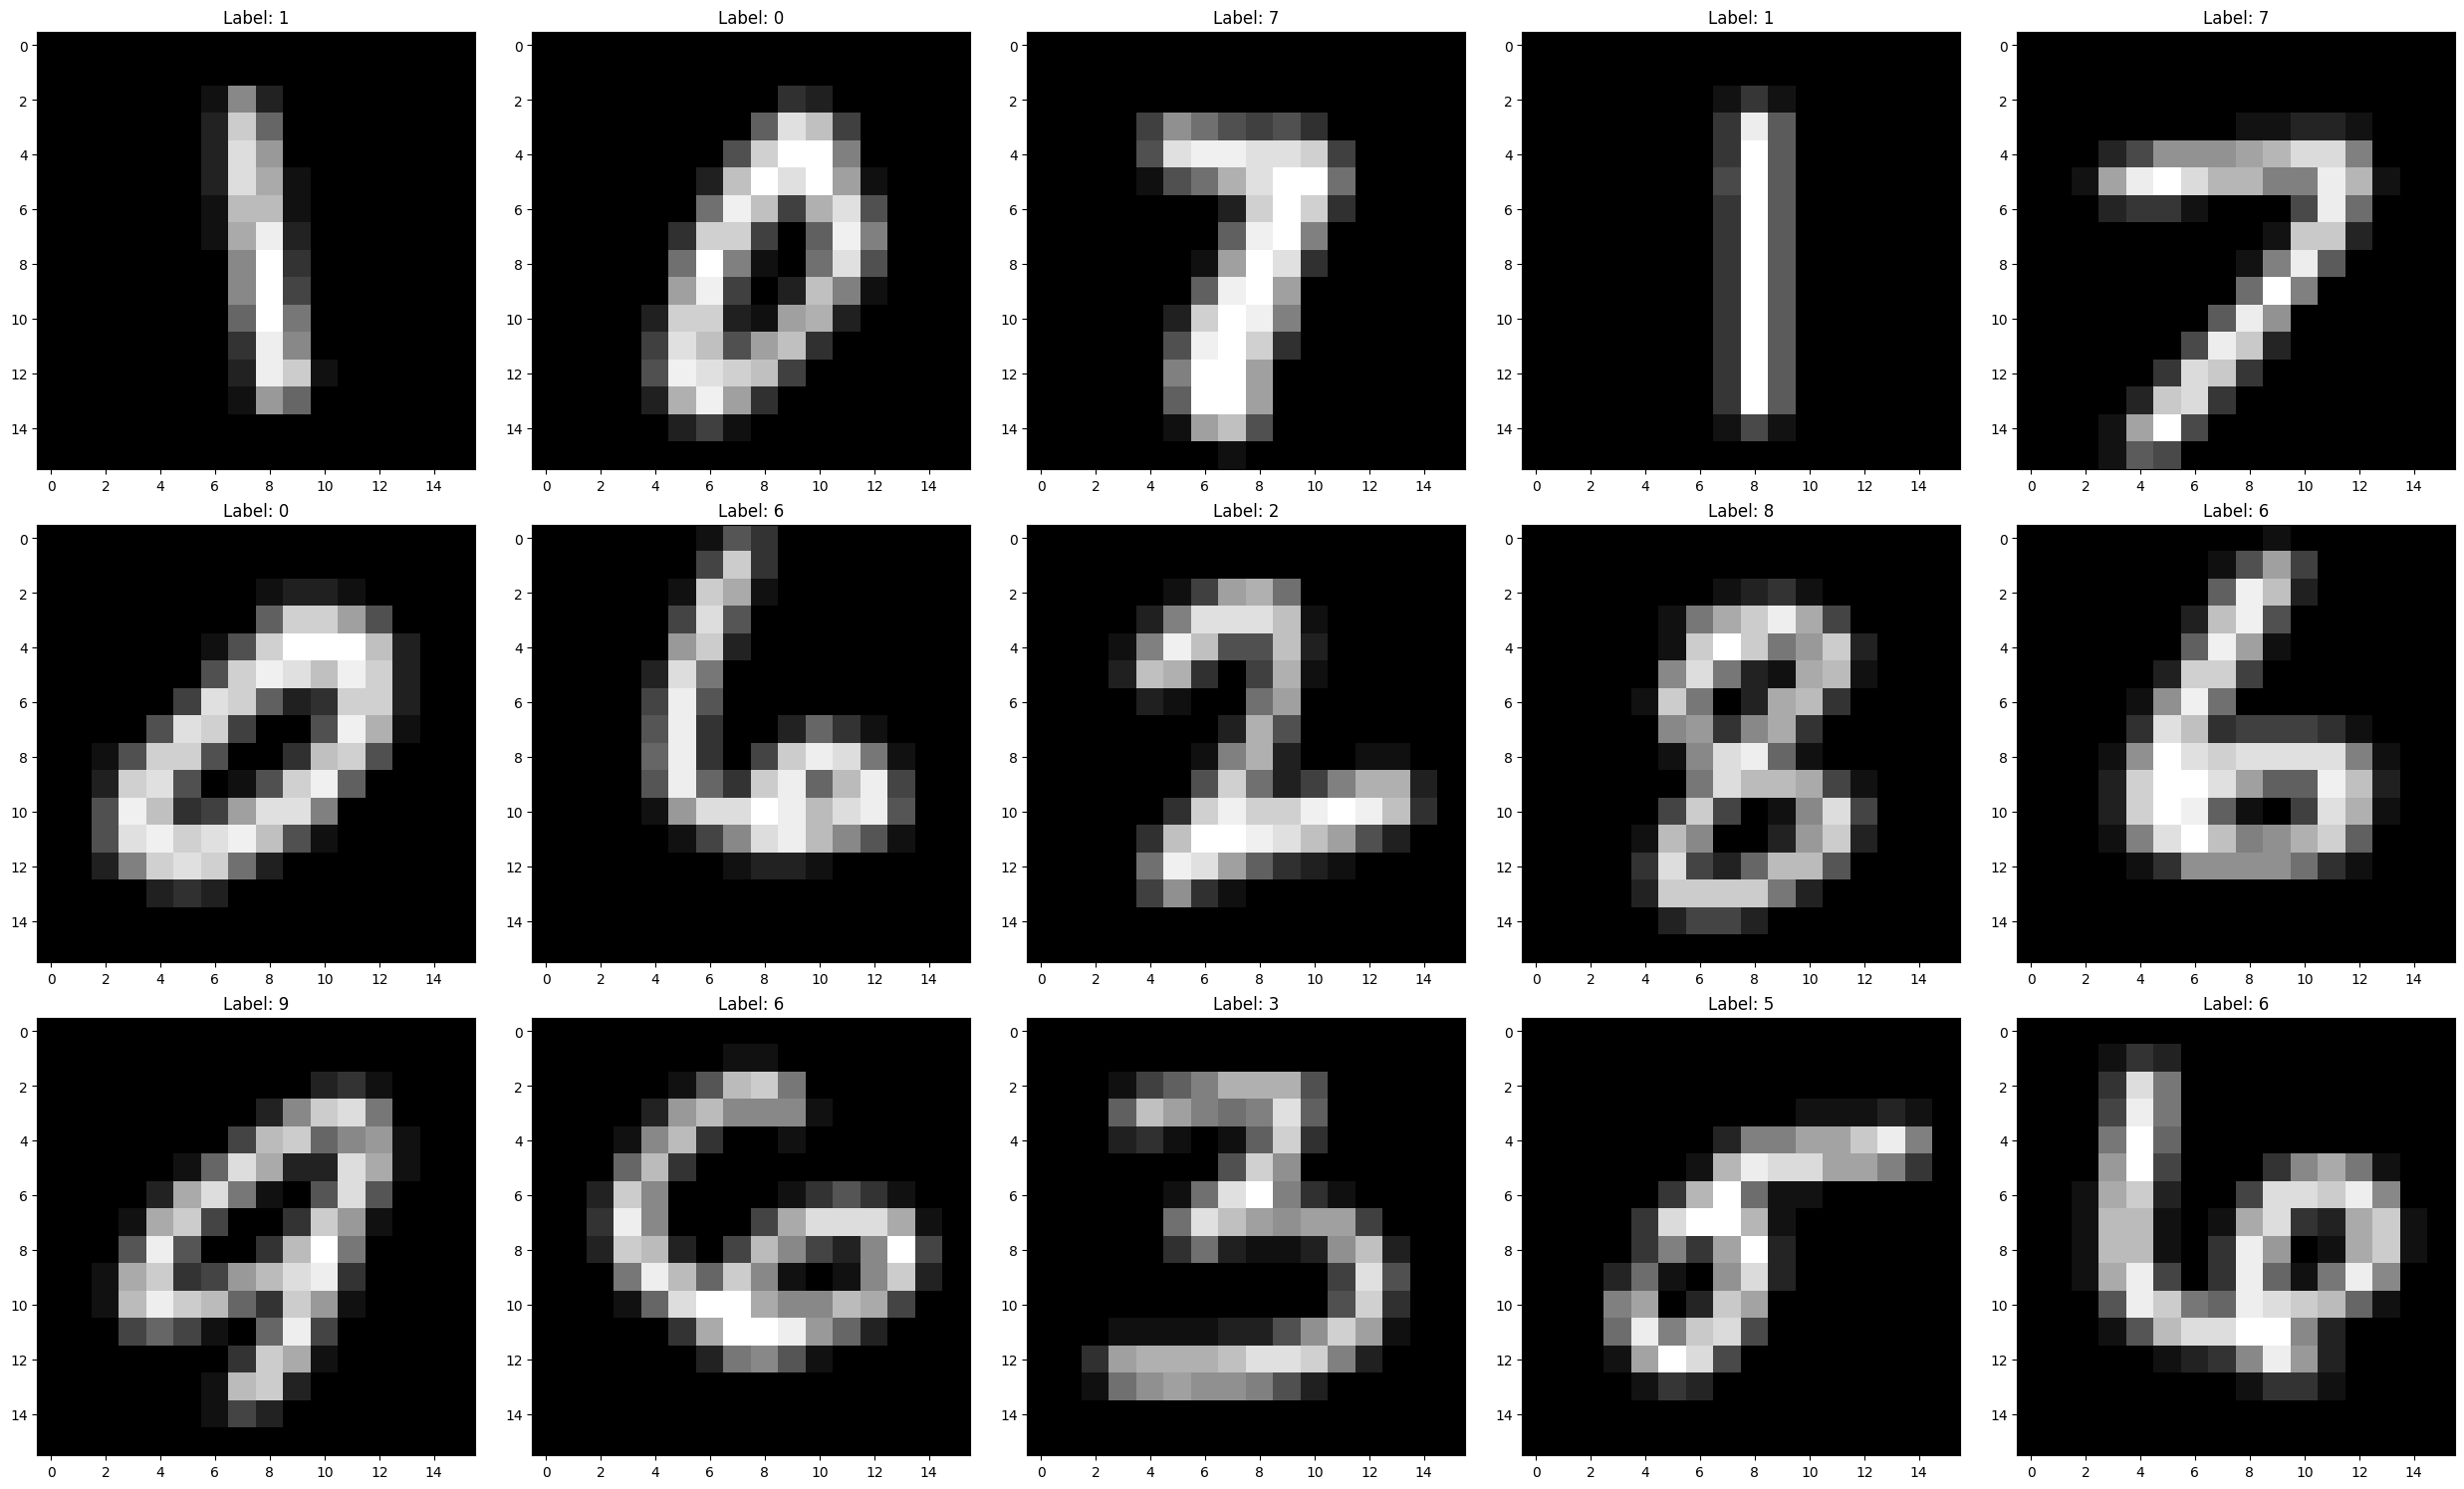

In [ ]:
import matplotlib.pyplot as plt

seed = 71
rng = np.random.default_rng(seed)
fig, axes = plt.subplots(3, 5, figsize=(25, 15))

axes = axes.flatten()
for ax in axes:
	i = rng.integers(0, len(all_blocks.subsets[0].train.X))
	ax.imshow(all_blocks.subsets[0].train.X[i], cmap=plt.cm.gray)
	ax.set_title("Label: " + str(all_blocks.subsets[0].train.y[i]))

plt.tight_layout()
plt.show()